<a href="https://colab.research.google.com/github/BenCoop16/IS-477/blob/main/is477_proj_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Bitcoin Reddit Sentiment Project**

###Installs and Imports

In [5]:
!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [6]:
import requests
import pandas as pd
import datetime
import time
import yfinance as yf
import time
from google.colab import files
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

##**Data Imports**

###Reddit Sentiment Data via Arctic Shift

In [7]:
all_posts = []

start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 1, 1)
posts_per_week = 30

current = start_date
while current < end_date:
    next_week = current + timedelta(weeks=1)

    params = {
        "subreddit": "Bitcoin",
        "after": current.strftime("%Y-%m-%d"),
        "before": next_week.strftime("%Y-%m-%d"),
        "limit": posts_per_week,
        "sort": "asc"
    }

    response = requests.get("https://arctic-shift.photon-reddit.com/api/posts/search", params=params)
    batch = response.json().get('data') or []

    if batch:
        all_posts.extend(batch)

    print(f"Week of {current.date()}: {len(batch)} posts, total: {len(all_posts)}")
    current = next_week
    time.sleep(0.5)

Week of 2024-01-01: 30 posts, total: 30
Week of 2024-01-08: 30 posts, total: 60
Week of 2024-01-15: 30 posts, total: 90
Week of 2024-01-22: 30 posts, total: 120
Week of 2024-01-29: 30 posts, total: 150
Week of 2024-02-05: 30 posts, total: 180
Week of 2024-02-12: 30 posts, total: 210
Week of 2024-02-19: 30 posts, total: 240
Week of 2024-02-26: 30 posts, total: 270
Week of 2024-03-04: 30 posts, total: 300
Week of 2024-03-11: 30 posts, total: 330
Week of 2024-03-18: 30 posts, total: 360
Week of 2024-03-25: 30 posts, total: 390
Week of 2024-04-01: 30 posts, total: 420
Week of 2024-04-08: 30 posts, total: 450
Week of 2024-04-15: 30 posts, total: 480
Week of 2024-04-22: 30 posts, total: 510
Week of 2024-04-29: 30 posts, total: 540
Week of 2024-05-06: 30 posts, total: 570
Week of 2024-05-13: 30 posts, total: 600
Week of 2024-05-20: 30 posts, total: 630
Week of 2024-05-27: 30 posts, total: 660
Week of 2024-06-03: 30 posts, total: 690
Week of 2024-06-10: 30 posts, total: 720
Week of 2024-06-17:

In [8]:
df_bitcoin = pd.DataFrame(all_posts)[['id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit']]
df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['created_utc'], unit='s')
print(df_bitcoin.shape)

(3150, 9)


In [9]:
df_bitcoin.head()

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp
0,18vkhs0,Crypto Trading at Bybit! Sign up,[removed],1,1.0,0,1704067279,Bitcoin,2024-01-01 00:01:19
1,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.0,1,1704067351,Bitcoin,2024-01-01 00:02:31
2,18vkl5i,Crypto Trading at Bybit! Sign up at,[removed],1,1.0,1,1704067574,Bitcoin,2024-01-01 00:06:14
3,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.0,2,1704067808,Bitcoin,2024-01-01 00:10:08
4,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.0,7,1704068581,Bitcoin,2024-01-01 00:23:01


###Bitcoin Price Data Upload

In [10]:
df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")
df_price_clean = df_price.copy()
df_price_clean.columns = ['close', 'high', 'low', 'open', 'volume']
df_price_clean = df_price_clean.reset_index()
df_price_clean.columns = ['date', 'close', 'high', 'low', 'open', 'volume']
df_price_clean['date'] = pd.to_datetime(df_price_clean['date'])
df_price_clean['price_change'] = df_price_clean['close'].diff()
df_price_clean['price_pct_change'] = df_price_clean['close'].pct_change() * 100
df_price_clean.to_csv('crypto_prices_raw.csv', index=False)
print(df_price_clean.shape)
print(df_price_clean.head())

/tmp/ipykernel_11334/3247487521.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")
[*********************100%***********************]  1 of 1 completed

(105, 8)
        date         close          high           low          open  \
0 2024-01-01  43943.097656  45899.707031  40813.535156  42280.234375   
1 2024-01-08  41796.269531  48969.371094  41724.613281  43948.707031   
2 2024-01-15  41545.785156  43566.273438  40297.457031  41715.066406   
3 2024-01-22  42035.593750  42797.175781  38521.894531  41553.652344   
4 2024-01-29  42583.582031  43838.945312  41818.332031  42030.914062   

         volume  price_change  price_pct_change  
0  202311773985           NaN               NaN  
1  259971819745  -2146.828125         -4.885473  
2  139135824835   -250.484375         -0.599298  
3  155314602893    489.808594          1.178961  
4  135184187433    547.988281          1.303629  


In [11]:
df_price.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,43943.097656,45899.707031,40813.535156,42280.234375,202311773985
2024-01-08,41796.269531,48969.371094,41724.613281,43948.707031,259971819745
2024-01-15,41545.785156,43566.273438,40297.457031,41715.066406,139135824835
2024-01-22,42035.593750,42797.175781,38521.894531,41553.652344,155314602893
2024-01-29,42583.582031,43838.945312,41818.332031,42030.914062,135184187433


##**Data Cleaning Process**

In [12]:
print("Duplicates:", df_bitcoin.duplicated(subset='id').sum())
print("\nMissing values:")
print(df_bitcoin.isnull().sum())
print("\nRemoved posts (selftext is [removed]):", (df_bitcoin['selftext'] == '[removed]').sum())
print("Deleted posts (selftext is [deleted]):", (df_bitcoin['selftext'] == '[deleted]').sum())

Duplicates: 0

Missing values:
id              0
title           0
selftext        0
score           0
upvote_ratio    0
num_comments    0
created_utc     0
subreddit       0
timestamp       0
dtype: int64

Removed posts (selftext is [removed]): 820
Deleted posts (selftext is [deleted]): 12


In [13]:
df_bitcoin_clean = df_bitcoin[df_bitcoin['selftext'] != '[removed]']
df_bitcoin_clean = df_bitcoin_clean[df_bitcoin_clean['selftext'] != '[deleted]']
df_bitcoin_clean = df_bitcoin_clean.drop_duplicates(subset='id')
df_bitcoin_clean = df_bitcoin_clean.reset_index(drop=True)
print(df_bitcoin_clean.shape)

(2318, 9)


In [14]:
print("Duplicates:", df_price.duplicated().sum())
print("\nMissing values:")
print(df_price.isnull().sum())
print("\nPrice data types:")
print(df_price.dtypes)

Duplicates: 0

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Price data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object


In [17]:
df_price_daily = yf.download('BTC-USD', start='2024-01-01', end='2026-01-01', interval='1d')
df_price_daily = df_price_daily.copy()
df_price_daily = df_price_daily.reset_index()
df_price_daily.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df_price_daily.columns]
df_price_daily['date'] = pd.to_datetime(df_price_daily['date'])
df_price_daily = df_price_daily.dropna(subset=['close'])

# Assign each trading day to its ISO week (Monday)
df_price_daily['week_start'] = (
    df_price_daily['date']
    - pd.to_timedelta(df_price_daily['date'].dt.dayofweek, unit='D')
)

print(df_price_daily.head())
print(df_price_daily.dtypes)

/tmp/ipykernel_11334/4157368096.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price_daily = yf.download('BTC-USD', start='2024-01-01', end='2026-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

        date         close          high           low          open  \
0 2024-01-01  44167.332031  44175.437500  42214.976562  42280.234375   
1 2024-01-02  44957.968750  45899.707031  44176.949219  44187.140625   
2 2024-01-03  42848.175781  45503.242188  40813.535156  44961.601562   
3 2024-01-04  44179.921875  44770.023438  42675.175781  42855.816406   
4 2024-01-05  44162.691406  44353.285156  42784.718750  44192.980469   

        volume week_start  
0  18426978443 2024-01-01  
1  39335274536 2024-01-01  
2  46342323118 2024-01-01  
3  30448091210 2024-01-01  
4  32336029347 2024-01-01  
date          datetime64[ns]
close                float64
high                 float64
low                  float64
open                 float64
volume                 int64
week_start    datetime64[ns]
dtype: object


In [18]:
df_bitcoin_clean['timestamp'] = pd.to_datetime(df_bitcoin_clean['created_utc'], unit='s')
df_bitcoin_clean['week_start'] = (
    df_bitcoin_clean['timestamp']
    - pd.to_timedelta(df_bitcoin_clean['timestamp'].dt.dayofweek, unit='D')
).dt.normalize()

print('Reddit date range:')
print(df_bitcoin_clean['week_start'].min())
print(df_bitcoin_clean['week_start'].max())

Reddit date range:
2024-01-01 00:00:00
2025-12-29 00:00:00


In [19]:
df_price_clean = (
    df_price_daily.sort_values('date')
    .groupby('week_start')
    .agg(
        open   = ('open',   'first'),
        close  = ('close',  'last'),
        high   = ('high',   'max'),
        low    = ('low',    'min'),
        volume = ('volume', 'mean'),
    )
    .reset_index()
)
df_price_clean.rename(columns={'week_start': 'date'}, inplace=True)

df_price_clean['price_change']     = df_price_clean['close'] - df_price_clean['open']
df_price_clean['price_pct_change'] = (df_price_clean['price_change'] / df_price_clean['open']) * 100

print(df_price_clean.shape)
print(df_price_clean.head())

(105, 8)
        date          open         close          high           low  \
0 2024-01-01  42280.234375  43943.097656  45899.707031  40813.535156   
1 2024-01-08  43948.707031  41796.269531  48969.371094  41724.613281   
2 2024-01-15  41715.066406  41545.785156  43566.273438  40297.457031   
3 2024-01-22  41553.652344  42035.593750  42797.175781  38521.894531   
4 2024-01-29  42030.914062  42583.582031  43838.945312  41818.332031   

         volume  price_change  price_pct_change  
0  2.890168e+10   1662.863281          3.932957  
1  3.713883e+10  -2152.437500         -4.897613  
2  1.987655e+10   -169.281250         -0.405804  
3  2.218780e+10    481.941406          1.159805  
4  1.931203e+10    552.667969          1.314908  


In [20]:
print('Weekly price rows:', len(df_price_clean))

Weekly price rows: 105


In [22]:
df_bitcoin_clean.to_csv('reddit_bitcoin_clean.csv', index=False)
df_price_clean.to_csv('crypto_prices_clean.csv', index=False)
print("All files saved!")

All files saved!


In [23]:
analyzer = SentimentIntensityAnalyzer()
df_bitcoin_clean['sentiment'] = df_bitcoin_clean['title'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
print(df_bitcoin_clean[['title', 'sentiment']].head(10))

                                               title  sentiment
0  Anyone using AI legitimately to trade better? ...     0.4404
1                       ETF approval, demand change?     0.3818
2  Mass Adoption after Mass Awareness - We are ge...     0.0000
3                                Bitcoin Yearly Lows    -0.2023
4                       Happy new year motherfuckers     0.5719
5  On the Lightning Network does the node operato...     0.3400
6                              This is where it ends     0.0000
7  Best place to store your Bitcoin from Coinbase...     0.8442
8  Yo why the Bitcoin fees so high right now is t...     0.0000
9                             Happy new year to all!     0.6114


In [25]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_bitcoin_clean['sentiment_label'] = df_bitcoin_clean['sentiment'].apply(label_sentiment)
print(df_bitcoin_clean['sentiment_label'].value_counts())

sentiment_label
neutral     1344
positive     621
negative     353
Name: count, dtype: int64


In [26]:
df_weekly_reddit = df_bitcoin_clean.groupby('week_start').agg(
    post_count       = ('id',              'count'),
    avg_score        = ('score',           'mean'),
    avg_upvote_ratio = ('upvote_ratio',    'mean'),
    avg_comments     = ('num_comments',    'mean'),
    avg_sentiment    = ('sentiment',       'mean'),
    positive_ratio   = ('sentiment_label', lambda x: (x == 'positive').sum() / len(x)),
    negative_ratio   = ('sentiment_label', lambda x: (x == 'negative').sum() / len(x)),
).reset_index()
df_weekly_reddit.rename(columns={'week_start': 'date'}, inplace=True)

print(df_weekly_reddit.shape)
print(df_weekly_reddit.head())

(105, 8)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio  
0       0.246454        0.500000        0.041667  
1       0.133475        0.333333        0.041667  
2       0.103381        0.346154        0.038462  
3       0.036675        0.291667        0.250000  
4       0.019376        0.320000        0.120000  


In [27]:
df_merged = pd.merge(df_weekly_reddit, df_price_clean, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(105, 15)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio          open         close  \
0       0.246454        0.500000        0.041667  42280.234375  43943.097656   
1       0.133475        0.333333        0.041667  43948.707031  41796.269531   
2       0.103381        0.346154        0.038462  41715.066406  41545.785156   
3       0.036675        0.291667        0.250000  41553.652344  42035.593750   
4       0.019376        0.320000        0.120000  42030.914062  42583.582031   

           high           low        volume  price_change  price_pct_change  
0  4

In [28]:
from scipy import stats

sentiment_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count', 'avg_score']
price_cols = ['close', 'price_change', 'price_pct_change', 'volume']

print('=== Pearson Correlation ===')
for sc in sentiment_cols:
    for pc in price_cols:
        subset = df_merged[[sc, pc]].dropna()
        r, p = stats.pearsonr(subset[sc], subset[pc])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {sc:25s} vs {pc:20s}: r={r:+.4f}, p={p:.4f} {sig}')

=== Pearson Correlation ===
  avg_sentiment             vs close               : r=-0.2145, p=0.0280 *
  avg_sentiment             vs price_change        : r=-0.0104, p=0.9165 
  avg_sentiment             vs price_pct_change    : r=-0.0293, p=0.7670 
  avg_sentiment             vs volume              : r=-0.1974, p=0.0435 *
  positive_ratio            vs close               : r=-0.1833, p=0.0612 
  positive_ratio            vs price_change        : r=-0.0531, p=0.5908 
  positive_ratio            vs price_pct_change    : r=-0.0706, p=0.4740 
  positive_ratio            vs volume              : r=-0.2301, p=0.0182 *
  negative_ratio            vs close               : r=+0.1965, p=0.0446 *
  negative_ratio            vs price_change        : r=-0.0339, p=0.7311 
  negative_ratio            vs price_pct_change    : r=-0.0116, p=0.9065 
  negative_ratio            vs volume              : r=+0.0859, p=0.3835 
  post_count                vs close               : r=-0.2007, p=0.0401 *
  pos

In [29]:
print('=== Lag Correlation: avg_sentiment vs. future weekly price_pct_change ===')
lag_results = []
for lag in range(0, min(5, len(df_merged) - 1)):
    df_lag = df_merged[['avg_sentiment', 'price_pct_change']].copy()
    df_lag['future_price_change'] = df_lag['price_pct_change'].shift(-lag)
    subset = df_lag.dropna()
    if len(subset) < 2:
        print(f'  Lag {lag} week(s): not enough data')
        continue
    r, p = stats.pearsonr(subset['avg_sentiment'], subset['future_price_change'])
    lag_results.append({'lag_weeks': lag, 'pearson_r': r, 'p_value': p})
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  Lag {lag} week(s): r={r:+.4f}, p={p:.4f} {sig}')

df_lag_results = pd.DataFrame(lag_results)

=== Lag Correlation: avg_sentiment vs. future weekly price_pct_change ===
  Lag 0 week(s): r=-0.0293, p=0.7670 
  Lag 1 week(s): r=-0.0978, p=0.3235 
  Lag 2 week(s): r=+0.0785, p=0.4305 
  Lag 3 week(s): r=+0.1718, p=0.0842 
  Lag 4 week(s): r=-0.0097, p=0.9231 


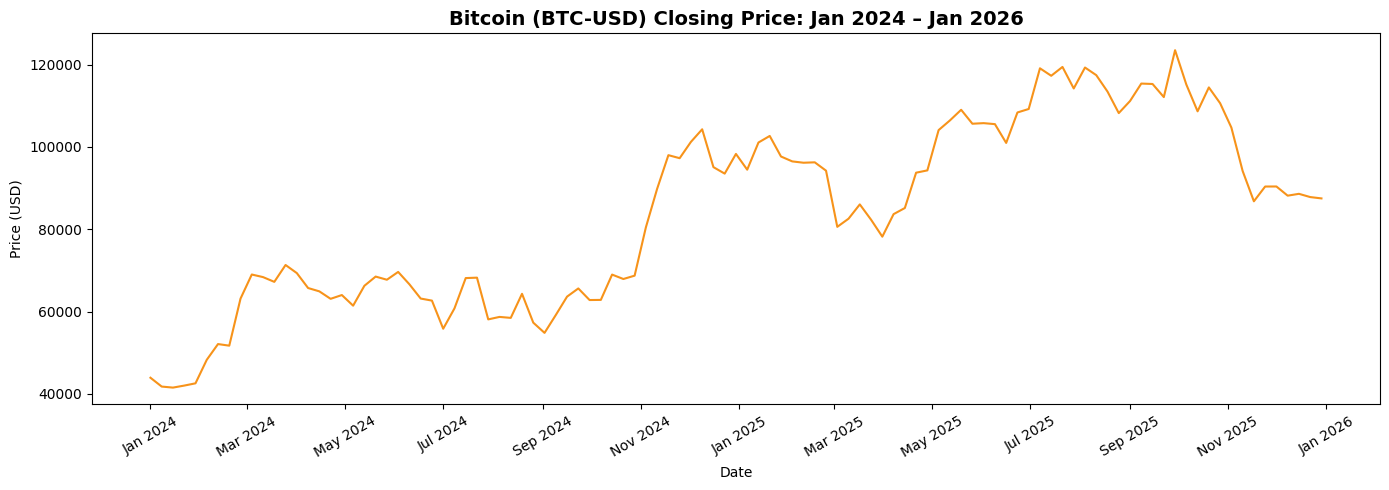

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5)
ax.set_title('Bitcoin (BTC-USD) Closing Price: Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_btc_price.png', dpi=150)
plt.show()

In [31]:
df_bitcoin_clean

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp,week_start,sentiment,sentiment_label
0,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.00,1,1704067351,Bitcoin,2024-01-01 00:02:31,2024-01-01,0.4404,positive
1,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.00,2,1704067808,Bitcoin,2024-01-01 00:10:08,2024-01-01,0.3818,positive
2,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.00,7,1704068581,Bitcoin,2024-01-01 00:23:01,2024-01-01,0.0000,neutral
3,18vkxzr,Bitcoin Yearly Lows,2012 - $4\n\n2013 - $65\n\n2014 - $200\n\n2015...,1,1.00,138,1704068769,Bitcoin,2024-01-01 00:26:09,2024-01-01,-0.2023,negative
4,18vkyzb,Happy new year motherfuckers,2023 was a good year. It was also a shitty yea...,1,1.00,4,1704068862,Bitcoin,2024-01-01 00:27:42,2024-01-01,0.5719,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
2313,1py995l,"If in doubt, zoom out…",,283,0.91,39,1766973207,Bitcoin,2025-12-29 01:53:27,2025-12-29,-0.3612,negative
2314,1py9fuo,Disappointed,I bought last year at £80k and listened to ton...,0,0.42,71,1766973705,Bitcoin,2025-12-29 02:01:45,2025-12-29,-0.4767,negative
2315,1py9o3p,"The initial predicament of $90,000 was resolve...",,2,1.00,0,1766974326,Bitcoin,2025-12-29 02:12:06,2025-12-29,0.1779,positive
2316,1py9vby,An interesting description of mining is it true?,,4083,0.98,188,1766974867,Bitcoin,2025-12-29 02:21:07,2025-12-29,0.6705,positive


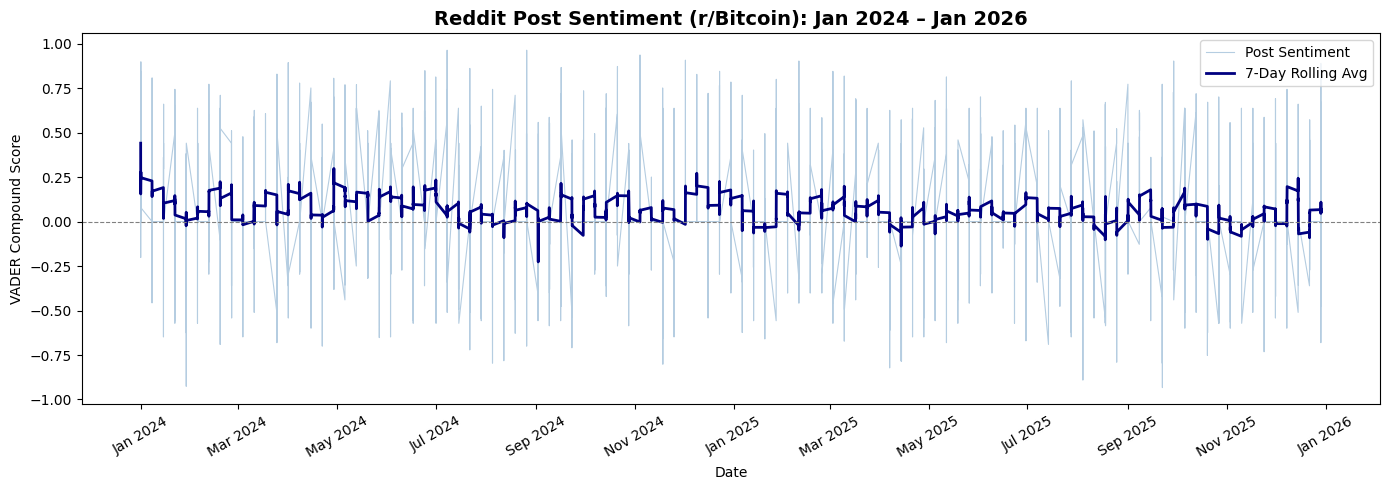

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_bitcoin_clean['timestamp'], df_bitcoin_clean['sentiment'],
        color='steelblue', linewidth=0.8, alpha=0.4, label='Post Sentiment')
rolling = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax.plot(rolling.index, rolling.values, color='navy', linewidth=2, label='7-Day Rolling Avg')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Reddit Post Sentiment (r/Bitcoin): Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VADER Compound Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig2_sentiment_over_time.png', dpi=150)
plt.show()

In [33]:
print(df_bitcoin_clean['week_start'].min())
print(df_bitcoin_clean['week_start'].max())
print(df_bitcoin_clean['week_start'].nunique(), 'unique weeks')

2024-01-01 00:00:00
2025-12-29 00:00:00
105 unique weeks


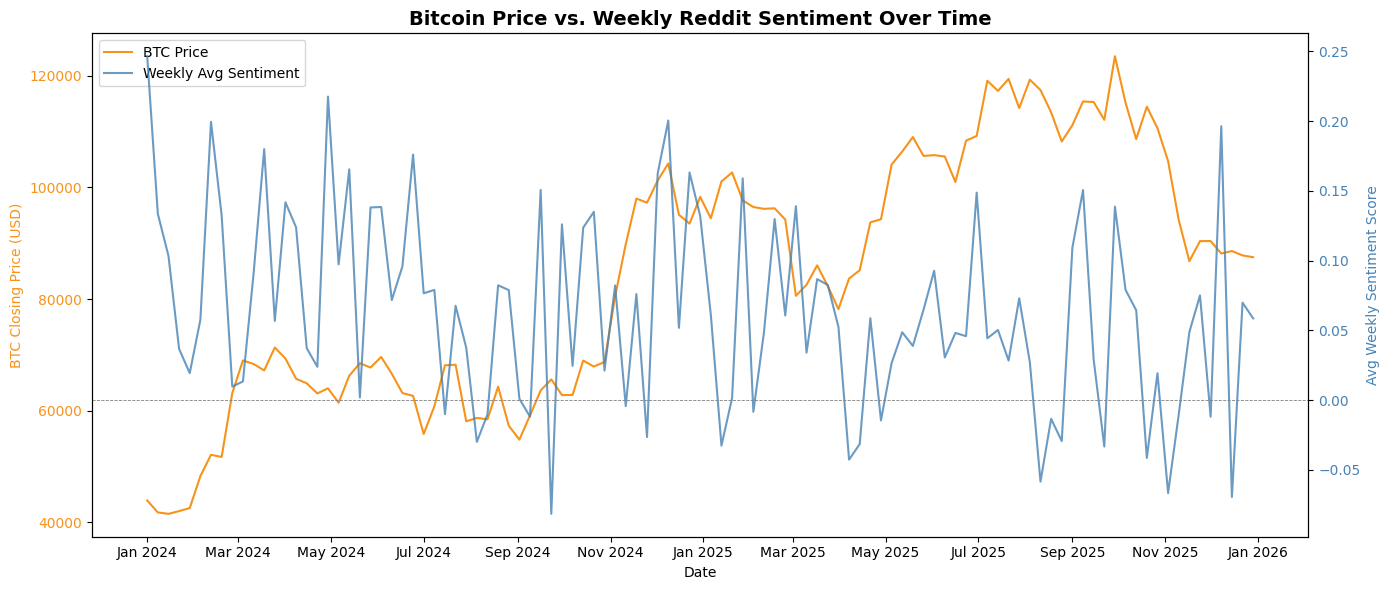

In [34]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5, label='BTC Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Closing Price (USD)', color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')

ax2 = ax1.twinx()
ax2.plot(df_merged['date'], df_merged['avg_sentiment'], color='steelblue', linewidth=1.5, alpha=0.8, label='Weekly Avg Sentiment')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax2.set_ylabel('Avg Weekly Sentiment Score', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Bitcoin Price vs. Weekly Reddit Sentiment Over Time', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig3_price_vs_sentiment.png', dpi=150)
plt.show()

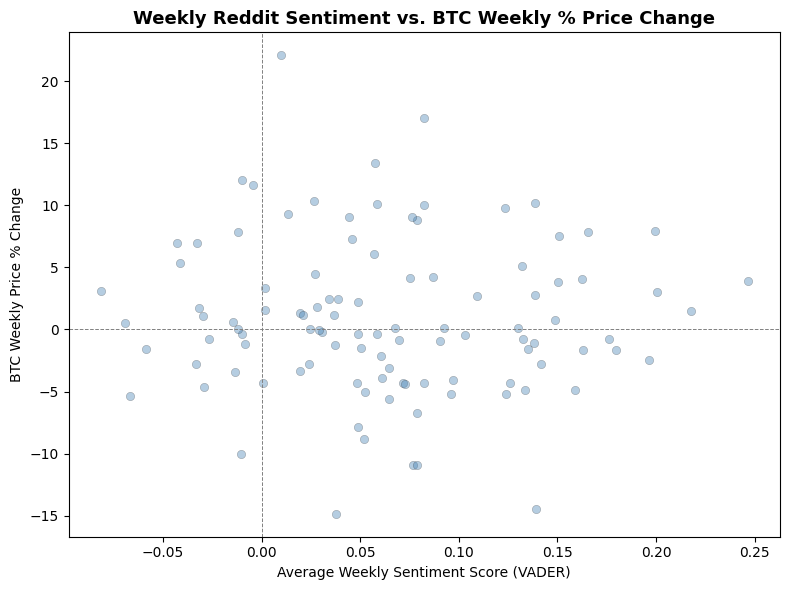

In [35]:
import numpy as np

subset = df_merged[['avg_sentiment', 'price_pct_change']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset['avg_sentiment'], subset['price_pct_change'],
           alpha=0.4, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_title('Weekly Reddit Sentiment vs. BTC Weekly % Price Change', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Weekly Sentiment Score (VADER)')
ax.set_ylabel('BTC Weekly Price % Change')
plt.tight_layout()
plt.savefig('fig4_scatter_sentiment_vs_price.png', dpi=150)
plt.show()

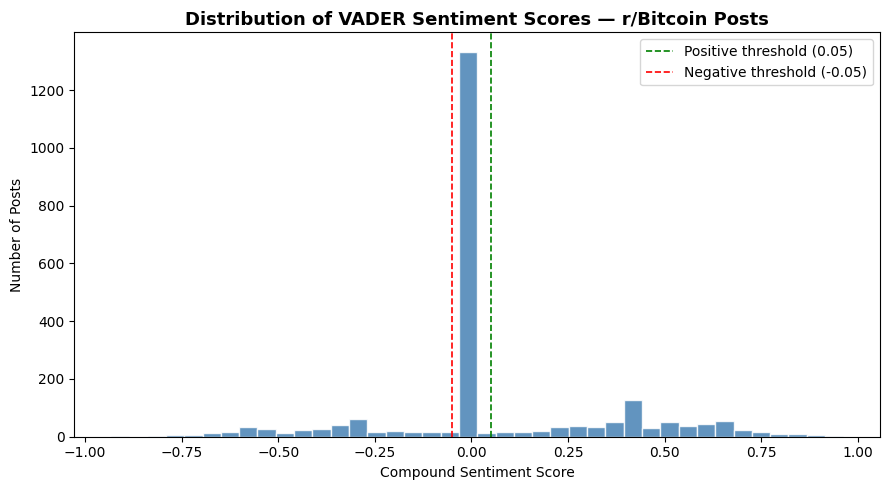

Positive: 621 posts (26.8%)
Neutral: 1344 posts (58.0%)
Negative: 353 posts (15.2%)


In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_bitcoin_clean['sentiment'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.05, color='green', linestyle='--', linewidth=1.2, label='Positive threshold (0.05)')
ax.axvline(-0.05, color='red', linestyle='--', linewidth=1.2, label='Negative threshold (-0.05)')
ax.set_title('Distribution of VADER Sentiment Scores — r/Bitcoin Posts', fontsize=13, fontweight='bold')
ax.set_xlabel('Compound Sentiment Score')
ax.set_ylabel('Number of Posts')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_sentiment_distribution.png', dpi=150)
plt.show()

counts = df_bitcoin_clean['sentiment_label'].value_counts()
total = len(df_bitcoin_clean)
for label in ['positive', 'neutral', 'negative']:
    n = counts.get(label, 0)
    print(f'{label.capitalize()}: {n} posts ({n/total*100:.1f}%)')

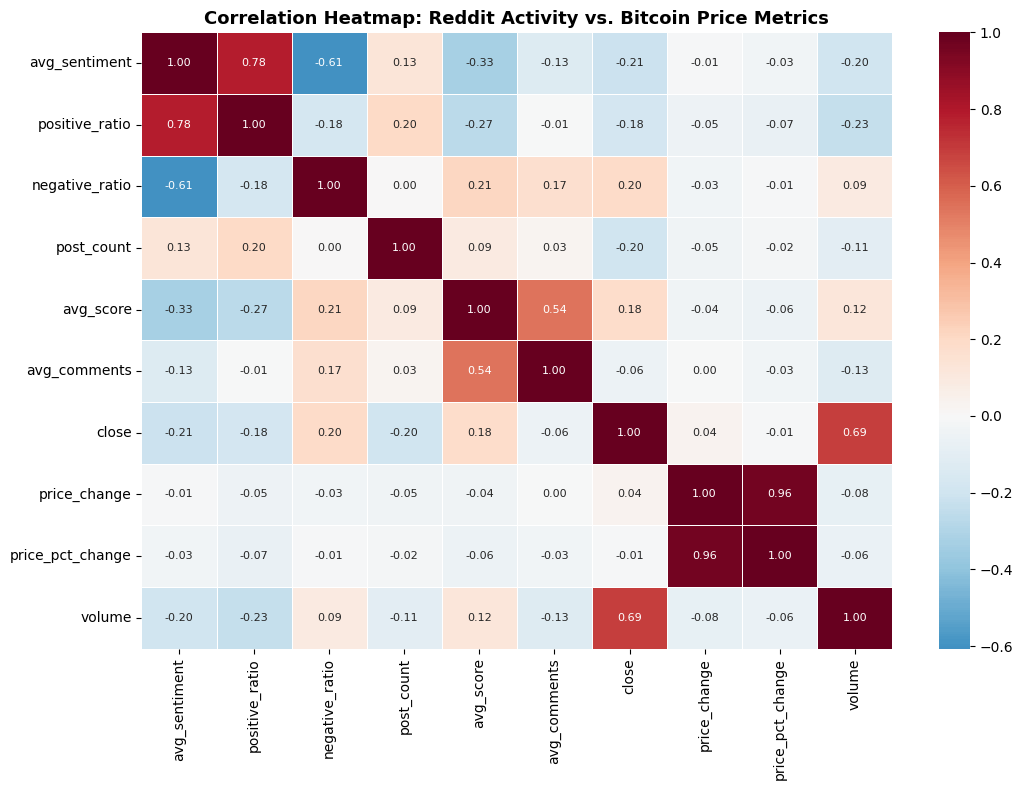

In [37]:
import seaborn as sns
heatmap_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count',
                'avg_score', 'avg_comments', 'close', 'price_change', 'price_pct_change', 'volume']
corr_matrix = df_merged[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap: Reddit Activity vs. Bitcoin Price Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', dpi=150)
plt.show()

/tmp/ipykernel_11334/505581996.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='sentiment_label', y='price_pct_change',


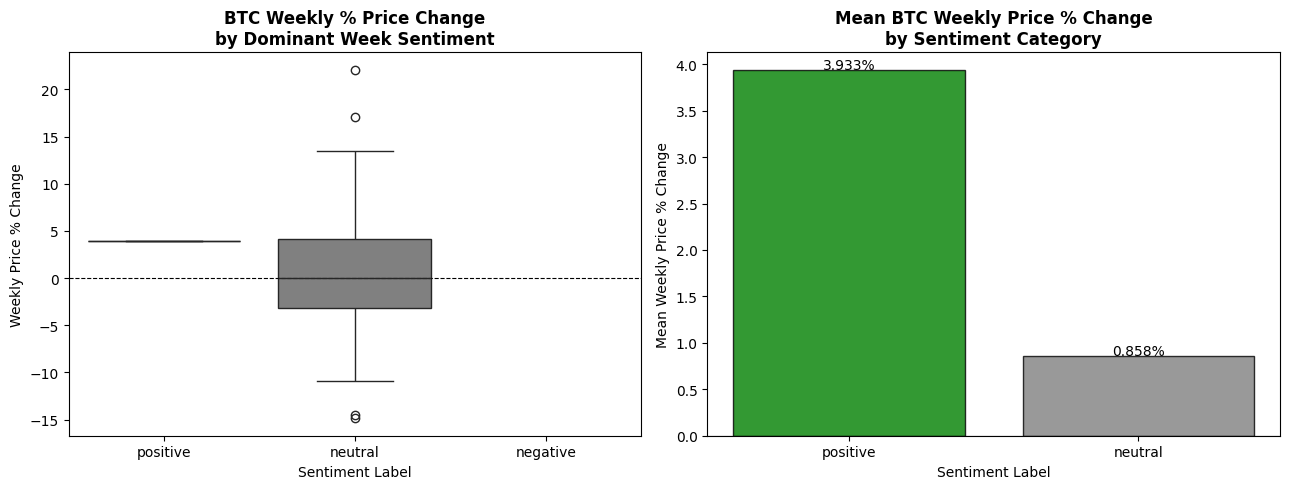

In [38]:
def weekly_sentiment_label(row):
    if row['positive_ratio'] > row['negative_ratio'] and row['positive_ratio'] >= 0.5:
        return 'positive'
    elif row['negative_ratio'] > row['positive_ratio'] and row['negative_ratio'] >= 0.5:
        return 'negative'
    else:
        return 'neutral'

df_merged['sentiment_label'] = df_merged.apply(weekly_sentiment_label, axis=1)

order = ['positive', 'neutral', 'negative']
palette = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_merged, x='sentiment_label', y='price_pct_change',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('BTC Weekly % Price Change\nby Dominant Week Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Weekly Price % Change')
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)

means = df_merged.groupby('sentiment_label')['price_pct_change'].mean().reindex(order)
bars = axes[1].bar(means.index, means.values,
                   color=[palette[k] for k in means.index], alpha=0.8, edgecolor='k')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean BTC Weekly Price % Change\nby Sentiment Category', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Mean Weekly Price % Change')
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig8_price_by_sentiment_category.png', dpi=150)
plt.show()

In [40]:
from scipy import stats

# ── RQ1: Avg weekly sentiment vs BTC price change at 1-, 2-, 3-week lags ──
print('RQ1: Avg Weekly Sentiment vs. Future BTC Weekly Price % Change')
for lag in [1, 2, 3]:
    df_merged[f'lag{lag}'] = df_merged['price_pct_change'].shift(-lag)
    subset = df_merged[['avg_sentiment', f'lag{lag}']].dropna()
    r, p = stats.pearsonr(subset['avg_sentiment'], subset[f'lag{lag}'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'  Lag {lag} week(s): r = {r:+.4f}, p = {p:.4f} {sig} (n={len(subset)})')

# ── RQ2: High-upvote (>75th pct) vs low-upvote sentiment → next-week price ──
q75 = df_merged['avg_score'].quantile(0.75)
df_merged['next_week_pct'] = df_merged['price_pct_change'].shift(-1)

print(f'\nRQ2: High vs. Low Upvote Posts vs. Next-Week BTC Price (75th pct = {q75:.0f})')
for label, group in [('High (>75th pct)', df_merged[df_merged['avg_score'] > q75]),
                     ('Low (<=75th pct)', df_merged[df_merged['avg_score'] <= q75])]:
    subset = group[['avg_sentiment', 'next_week_pct']].dropna()
    r, p = stats.pearsonr(subset['avg_sentiment'], subset['next_week_pct'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'  {label}: r = {r:+.4f}, p = {p:.4f} {sig} (n={len(subset)})')

RQ1: Avg Weekly Sentiment vs. Future BTC Weekly Price % Change
  Lag 1 week(s): r = -0.0978, p = 0.3235 n.s. (n=104)
  Lag 2 week(s): r = +0.0785, p = 0.4305 n.s. (n=103)
  Lag 3 week(s): r = +0.1718, p = 0.0842 n.s. (n=102)

RQ2: High vs. Low Upvote Posts vs. Next-Week BTC Price (75th pct = 94)
  High (>75th pct): r = -0.2167, p = 0.2982 n.s. (n=25)
  Low (<=75th pct): r = -0.0365, p = 0.7495 n.s. (n=79)


## Findings

**RQ1: Does average weekly r/Bitcoin sentiment correlate with Bitcoin's closing price change within a 1–3 week window?**

No statistically significant correlation was found at any lag. Pearson correlations between average weekly sentiment and future BTC price % change were weak across all three windows (lag 1: r = -0.0978, p = 0.3235; lag 2: r = +0.0785, p = 0.4305; lag 3: r = +0.1718, p = 0.0842), with none reaching the p < 0.05 threshold. Notably, the lag 3 result approached significance with the largest effect size observed, suggesting a weak delayed relationship may be worth exploring with a larger sample. Overall, r/Bitcoin sentiment alone does not appear to be a reliable short-term predictor of Bitcoin price movement.

**RQ2: Do posts with upvote scores above the 75th percentile show a stronger correlation with next-week Bitcoin price movements?**

High-upvote posts (score > 94) did show a slightly stronger correlation with next-week price change (r = -0.2167, p = 0.2982, n=25) compared to low-upvote posts (r = -0.0365, p = 0.7495, n=79), but neither result was statistically significant. The smaller sample size of high-upvote posts limits the reliability of this comparison. While the direction of the effect is consistent — higher-engagement posts trending negative relative to next-day returns — no conclusive evidence supports the hypothesis that upvote score amplifies predictive signal.

**Overall:** Across both research questions, the results suggest that Reddit sentiment from r/Bitcoin does not significantly predict short-term Bitcoin price movements in this dataset. The weak, non-significant correlations may reflect the noisy, speculative nature of crypto markets, the limitations of title-only VADER sentiment analysis, or the need for a longer or denser post dataset to detect subtler effects.